### Import

In [12]:
from unified_planning.engines import PlanGenerationResultStatus
import json
import time
import os
import pandas as pd
import matplotlib.pyplot as plt
from planner.conf import ACTION_COSTS
from planner.problem import NetworkHardeningProblem
import numpy as np

In [13]:
pathInput = 'input'
pathInputScenarios = pathInput + '/scenarios'
pathOutput = 'output'
pathOutputPlans = pathOutput + '/plans'

if not os.path.exists(pathOutput):
    os.makedirs(pathOutput)
if not os.path.exists(pathOutputPlans):
    os.makedirs(pathOutputPlans)

### Utility Functions

In [14]:
def get_action_type(action_name):
    name = action_name.lower()
    
    if "block_port_firewall" in name:
        return 'block_port_firewall'

    elif "disable_service" in name:
        return 'disable_service'
    
    elif "migrate_service" in name:
        return 'migrate_service'
    
    elif "patch_service" in name:
        return 'patch_service'
    
    elif "reuse_service" in name:
        return 'reuse_service'
    
    elif "reuse_vulnerable_service" in name:
        return 'reuse_vulnerable_service'
    
    elif "disable_vulnerable_service" in name:
        return 'disable_vulnerable_service'
    
    elif "patch_critical_service" in name:
        return 'patch_critical_service'
    return 'other'

In [15]:
def run_all_scenarios():

    # Read all scenario files
    files = sorted([f for f in os.listdir(pathInputScenarios) if f.endswith('.json')])
    results = [] 

    for filename in files:
        with open(f'{pathInputScenarios}/{filename}') as f:
            scenario = json.load(f)

        name = scenario['scenario_name']

        # --- Header scenario ---
        print(f"\n{'─' * 140}")
        print(f"Scenario: {name}")
        print(f"  {scenario.get('description', '')}")
        
        # --- Descriptive statistics ---
        problem = NetworkHardeningProblem(scenario)
        print(f"    Objects: {len(problem.problem.all_objects)}, "
              f"Actions: {len(problem.problem.actions)}, "
              f"Goals: {len(problem.problem.goals)}\n")


        # --- Solve ---
        start = time.time()
        result, _ = problem.solve()
        elapsed = time.time() - start

        # --- Metrics ---
        metrics = {
            'scenario': name,
            'status': 'ERROR',
            'time': round(elapsed, 3),
            'actions': 0,
            'cost': 0,
            'block_port_firewall': 0,
            'disable_service': 0,
            'migrate_service': 0,
            'patch_service': 0,
            'reuse_service': 0,
            'reuse_vulnerable_service': 0,
            'disable_vulnerable_service': 0,
            'patch_critical_service': 0
        }

        # --- Analyze result ---
        if result is None:
            print(f"\n  Result: ERROR")

        elif result.status not in [PlanGenerationResultStatus.SOLVED_SATISFICING,
                                    PlanGenerationResultStatus.SOLVED_OPTIMALLY]:
            metrics['status'] = 'UNSOLVABLE'
            print(f"\n  Result: UNSOLVABLE in {elapsed:.3f}s")

        else:
            # Plan is valid and can be analyzed
            metrics['status'] = 'SUCCESS'
            plan = [str(a) for a in result.plan.actions]
            metrics['actions'] = len(plan)

            for action in plan:
                print(f"    {action}")
                action_type = get_action_type(action)
                if action_type == 'block_port_firewall':
                    metrics['block_port_firewall'] += 1
                    metrics['cost'] += ACTION_COSTS['block_port_firewall']
                elif action_type == 'disable_service':
                    metrics['disable_service'] += 1
                    metrics['cost'] += ACTION_COSTS['disable_service']
                elif action_type == 'migrate_service':
                    metrics['migrate_service'] += 1
                    metrics['cost'] += ACTION_COSTS['migrate_service']
                elif action_type == 'patch_service':
                    metrics['patch_service'] += 1
                    metrics['cost'] += ACTION_COSTS['patch_service']
                elif action_type == 'reuse_service':
                    metrics['reuse_service'] += 1
                    metrics['cost'] += ACTION_COSTS['reuse_service']
                elif action_type == 'reuse_vulnerable_service':
                    metrics['reuse_vulnerable_service'] += 1
                    metrics['cost'] += ACTION_COSTS['reuse_vulnerable_service']
                elif action_type == 'disable_vulnerable_service':
                    metrics['disable_vulnerable_service'] += 1
                    metrics['cost'] += ACTION_COSTS['disable_vulnerable_service']
                elif action_type == 'patch_critical_service':
                    metrics['patch_critical_service'] += 1
                    metrics['cost'] += ACTION_COSTS['patch_critical_service']

            print(f"\n  Result: SOLVED in {elapsed:.3f}s")
            print(f"  Plan: {len(plan)} actions, total cost {metrics['cost']}")
            print(f"  Details: {metrics['migrate_service']} migrations, "
                  f"{metrics['disable_service']} disables, "
                  f"{metrics['block_port_firewall']} block_port_firewall, "
                  f"{metrics['patch_service']} patch_service, "
                  f"{metrics['reuse_service']} reuse_service, "
                  f"{metrics['reuse_vulnerable_service']} reuse_vulnerable_service, "
                  f"{metrics['disable_vulnerable_service']} disable_vulnerable_service, "
                  f"{metrics['patch_critical_service']} patch_critical_service")

            # Salva il piano in un file
            with open(f"{pathOutputPlans}/plan_{name}.txt", 'w') as f:
                f.write(f"Plan for: {name}\n")
                f.write(f"{'=' * 50}\n\n")
                for i, action in enumerate(plan, 1):
                    f.write(f"{i:3d}. {action}\n")

        results.append(metrics)

    return pd.DataFrame(results)

## Planning

In [16]:
df_results = run_all_scenarios()


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Scenario: 01_all_actions_basic
  A basic scenario with three hosts, each with a mix of open ports and services. The policy forbids certain ports, and there are no critical services defined.
    Objects: 27, Actions: 9, Goals: 7

  *** Credits ***
  * In operation mode `Compiler` at line 660 of `c:\Users\Federico\DesktopW\network-hardening-planner\.venv\Lib\site-packages\unified_planning\shortcuts.py`, you are using the following planning engine:
  * Engine name: Fast Downward
  * Developers:  Uni Basel team and contributors (cf. https://github.com/aibasel/downward/blob/main/README.md)
  * Description: Fast Downward is a domain-independent classical planning system.

  *** Credits ***
  * In operation mode `OneshotPlanner` at line 563 of `c:\Users\Federico\DesktopW\network-hardening-planner\.venv\Lib\site-packages\unified_planning\shortcuts.py`, y

### Analysis

In [17]:
# --- Print summary ---
print("\n" + "=" * 140)
print("SUMMARY OF RESULTS")
print("=" * 140 + "\n")

# Print the formatted DataFrame
print(df_results.to_string(index=False))

# Save as CSV for further analysis
df_results.to_csv(pathOutput + '/summary.csv', index=False)
print("\nResults saved in '" + pathOutput + "/summary.csv'")


SUMMARY OF RESULTS

            scenario     status   time  actions  cost  block_port_firewall  disable_service  migrate_service  patch_service  reuse_service  reuse_vulnerable_service  disable_vulnerable_service  patch_critical_service
01_all_actions_basic    SUCCESS  0.893        5    58                    1                0                2              1              1                         0                           0                       0
 02_deps_all_actions    SUCCESS  0.905        5    52                    2                0                1              0              1                         0                           1                       0
 03_enterprise_mixed    SUCCESS  3.398       14   134                    5                3                2              1              1                         1                           0                       1
04_security_incident    SUCCESS  3.116       11   118                    4                2                3   

In [18]:
# --- Calculate statistics ---
print("\nSTATISTICS")
print("-" * 40)

# Count scenarios by status
n_success = len(df_results[df_results['status'] == 'SUCCESS'])
n_fail = len(df_results[df_results['status'] != 'SUCCESS'])

# Filter only solved scenarios to calculate statistics
df_ok = df_results[df_results['status'] == 'SUCCESS']

print(f"Solved :  {n_success}")
print(f"Unsolved: {n_fail}")

if len(df_ok) > 0:

    print(f"\nTotal actions executed: {int(df_ok['actions'].sum())}") 
    print(f"  - Migrations: {int(df_ok['migrate_service'].sum())}")
    print(f"  - Disables: {int(df_ok['disable_service'].sum()):}")
    print(f"  - Port Blocks: {int(df_ok['block_port_firewall'].sum()):}")
    print(f"  - Patch Service: {int(df_ok['patch_service'].sum()):}")
    print(f"  - Reuse Service: {int(df_ok['reuse_service'].sum()):}")
    print(f"  - Reuse Vulnerable Service: {int(df_ok['reuse_vulnerable_service'].sum()):}")
    print(f"  - Disable Vulnerable Service: {int(df_ok['disable_vulnerable_service'].sum()):}")
    print(f"  - Patch Critical Service: {int(df_ok['patch_critical_service'].sum()):}")

    print(f"\nTotal cost: {int(df_ok['cost'].sum()):}")
    print(f"Average time: {df_ok['time'].mean():.3f}s")


STATISTICS
----------------------------------------
Solved :  7
Unsolved: 1

Total actions executed: 95
  - Migrations: 19
  - Disables: 17
  - Port Blocks: 35
  - Patch Service: 3
  - Reuse Service: 14
  - Reuse Vulnerable Service: 2
  - Disable Vulnerable Service: 2
  - Patch Critical Service: 3

Total cost: 952
Average time: 4.887s


### Graphs

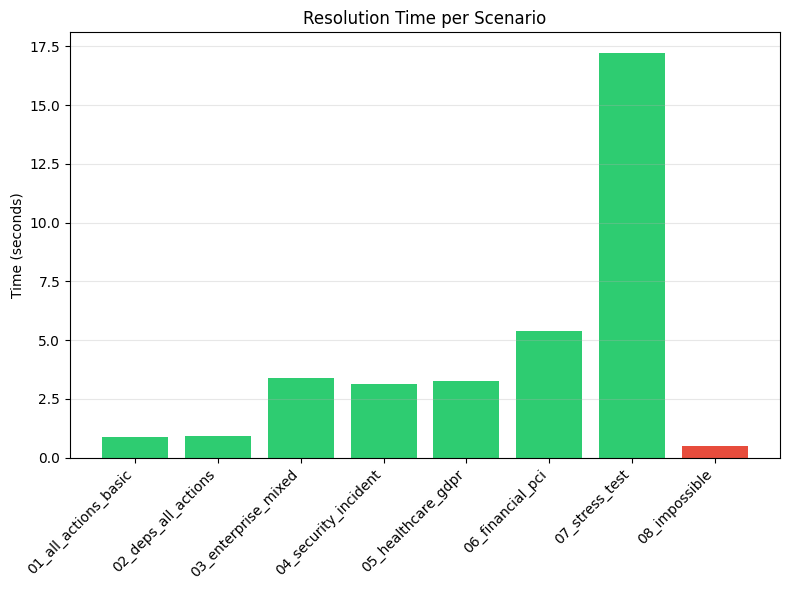

Chart saved: resolution_time.png


In [19]:
# --- CHART 1: Resolution time per scenario ---
plt.figure(figsize=(8, 6))
colors = ['#2ecc71' if s == 'SUCCESS' else '#e74c3c' for s in df_results['status']]

plt.bar(range(len(df_results)), df_results['time'], color=colors)
plt.xticks(range(len(df_results)), [s for s in df_results['scenario']], rotation=45, ha='right')
plt.ylabel('Time (seconds)')

plt.title('Resolution Time per Scenario')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(pathOutput + '/resolution_time.png', dpi=150)
plt.show()

print("Chart saved: resolution_time.png")

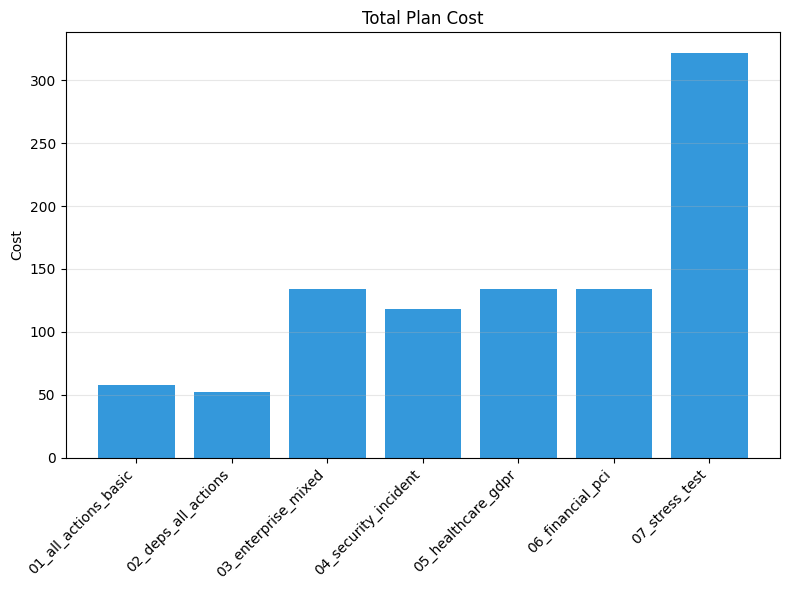

Chart saved: total_cost.png


In [20]:
# --- CHART 2: Total cost per scenario ---
plt.figure(figsize=(8, 6))

plt.bar(range(len(df_ok)), df_ok['cost'], color='#3498db')
plt.xticks(range(len(df_ok)), [s for s in df_ok['scenario']], rotation=45, ha='right')
plt.ylabel('Cost')

plt.title('Total Plan Cost')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(pathOutput + '/total_cost.png', dpi=150)
plt.show()

print("Chart saved: total_cost.png")

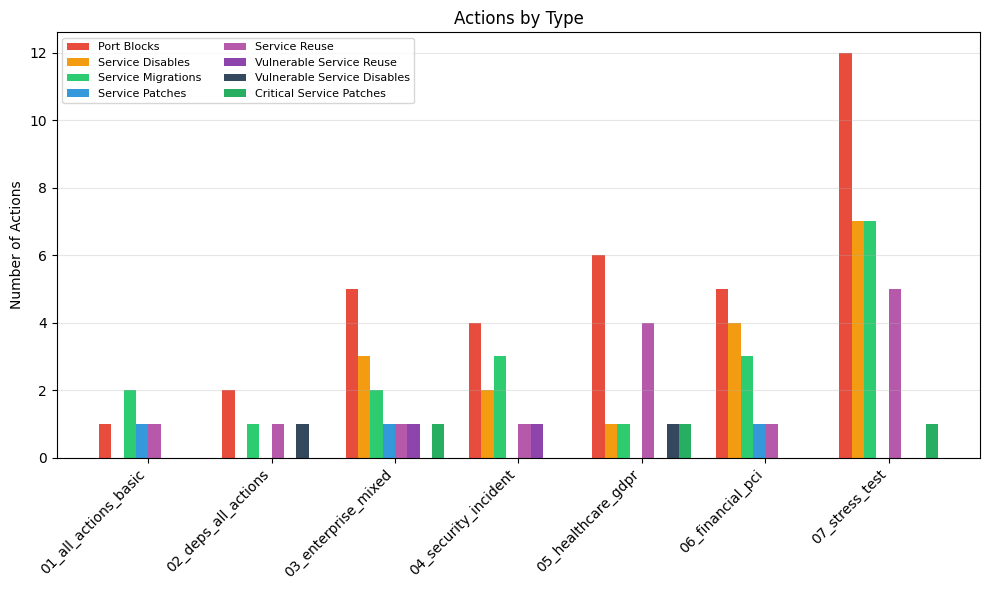

Chart saved: actions_by_type.png


In [25]:
# --- CHART 3: Actions by type ---
plt.figure(figsize=(10, 6))

action_cols = [
    'block_port_firewall',
    'disable_service',
    'migrate_service',
    'patch_service',
    'reuse_service',
    'reuse_vulnerable_service',
    'disable_vulnerable_service',
    'patch_critical_service'
]
labels = [
    'Port Blocks',
    'Service Disables',
    'Service Migrations',
    'Service Patches',
    'Service Reuse',
    'Vulnerable Service Reuse',
    'Vulnerable Service Disables',
    'Critical Service Patches'
]
colors_actions = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db', "#b659aa", '#8e44ad', '#34495e', '#27ae60']

x = np.arange(len(df_ok))
n_types = len(action_cols)
width = 0.8 / n_types  # fill ~80% of each scenario slot

for i, (col, label, color) in enumerate(zip(action_cols, labels, colors_actions)):
    offset = (i - (n_types - 1) / 2) * width
    plt.bar(x + offset, df_ok[col], width, label=label, color=color)

plt.xticks(x, df_ok['scenario'], rotation=45, ha='right')
plt.ylabel('Number of Actions')
plt.title('Actions by Type')
plt.legend(fontsize=8, ncol=2)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(pathOutput + '/actions_by_type.png', dpi=150)
plt.show()

print("Chart saved: actions_by_type.png")

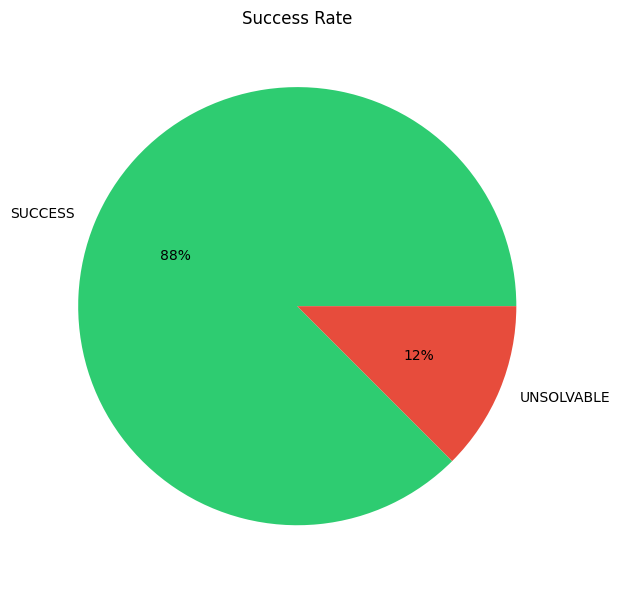

Chart saved: success_rate.png


In [22]:
# --- CHART 4: Success Rate (Pie Chart) ---
plt.figure(figsize=(8, 6))

counts = df_results['status'].value_counts()
colors_pie = ['#2ecc71' if s == 'SUCCESS' else '#e74c3c' for s in counts.index]
plt.pie(counts.values, labels=counts.index, autopct='%1.0f%%', colors=colors_pie)

plt.title('Success Rate')
plt.tight_layout()
plt.savefig(pathOutput + '/success_rate.png', dpi=150)
plt.show()

print("Chart saved: success_rate.png")